In [2]:
!pip3 install numpy matplotlib plotly nbformat


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import math


In [11]:
df = pd.read_csv('customer_data1.csv')
print(df.head())


   id  age  gender  income   education region loyalty_status  \
0   1   27    Male   40682    Bachelor   East           Gold   
1   2   29    Male   15317     Masters   West        Regular   
2   3   37    Male   38849    Bachelor   West         Silver   
3   4   30    Male   11568  HighSchool  South        Regular   
4   5   31  Female   46952     College  North        Regular   

  purchase_frequency  purchase_amount product_category  satisfaction_score  
0           frequent            18249            Books                   6  
1               rare             4557         Clothing                   6  
2               rare            11822         Clothing                   6  
3           frequent             4098             Food                   7  
4         occasional            19685         Clothing                   5  


In [12]:
df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id']).head(10000)
print(df.head())


   age  income  purchase_amount  satisfaction_score
0   27   40682            18249                   6
1   29   15317             4557                   6
2   37   38849            11822                   6
3   30   11568             4098                   7
4   31   46952            19685                   5


In [13]:
class KMeans:
    def __init__(self, n_clusters, data):
        self.k = n_clusters
        self.x = np.array(data)  # Đảm bảo dữ liệu là numpy.ndarray
        self.d = self.x.shape[1]  # Số chiều dữ liệu
        self.centroids = np.zeros((self.k, self.d))

        # Khởi tạo centroid ngẫu nhiên trong phạm vi dữ liệu
        for i in range(self.d):
            self.centroids[:, i] = np.random.uniform(np.min(self.x[:, i]), np.max(self.x[:, i]), size=self.k)

        self.labels = self.genLabels()
        self.colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'black', 4: 'purple', 5: 'orange', 6: 'brown'}

    def dist(self, p, q):
        return np.linalg.norm(p - q)  # Khoảng cách Euclidean

    def predict(self, p):
        return np.argmin([self.dist(p, centroid) for centroid in self.centroids])

    def genLabels(self):
        return np.array([self.predict(p) for p in self.x])

    def fit(self, epochs, step):
            print(f"\nFitting for {epochs} epochs with step of {step}")
            for epoch in range(epochs):
                for i, centroid in enumerate(self.centroids):
                    l = np.array([1 if item == i else 0 for item in self.labels])
                    
                    if np.sum(l) > 0:  # Tránh lỗi chia cho 0
                        temp = np.sum((self.x - centroid) * l[:, np.newaxis], axis=0) / np.sum(l)
                        self.centroids[i] += step * temp

                # Cập nhật nhãn mới
                self.labels = self.genLabels()

            print("Done fitting!\n")

    def showPlot(self, classification=False): # Dành cho 2 chiều

        if self.x.shape[1] != 2:
            print("Dữ liệu không phải 2 chiều, không thể hiển thị biểu đồ.")
            return
        
        plt.figure(figsize=(50, 50))

        if classification:
            handles = []  # Danh sách biểu tượng cho chú thích

            for i, p in enumerate(self.x):
                plt.scatter(p[0], p[1], color=self.colors[self.labels[i]])

            for i, centroid in enumerate(self.centroids):
                plt.scatter(centroid[0], centroid[1], color=self.colors[i], s=200, marker="o", linewidths=3, edgecolor='gray')
                
                # Thêm vào danh sách chú thích
                handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                        markerfacecolor=self.colors[i], markersize=10,
                                        label=f"Cluster {i}"))

            # Hiển thị chú thích ở góc trên bên trái
            plt.legend(handles=handles, loc="upper left", title="Clusters")

        else:
            plt.scatter(self.x[:, 0], self.x[:, 1], color='blue')
            plt.scatter(self.centroids[:, 0], self.centroids[:, 1], color="red", s=100,  marker="x", linewidths=3, edgecolor='gray')

        plt.show()


    def printCentroids(self):
        print("=" * 20)
        print("Centroids:")
        print(self.centroids)

    def calculate_wcss(self):
        return np.sum((self.x - self.centroids[self.labels]) ** 2)
    

In [14]:
def elbow_curve(X, max_k):
    wcss_values = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, data=X)
        kmeans.fit(epochs=100, step=1)  # Fit the model
        wcss = kmeans.calculate_wcss()    # Calculate WCSS for this k
        wcss_values.append(wcss)

    # Plotting the elbow curve
    plt.plot(range(1, max_k + 1), wcss_values, marker='o', color='b')
    plt.title('Elbow Curve')
    plt.xlabel('Số cụm K')
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
    plt.show()


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!



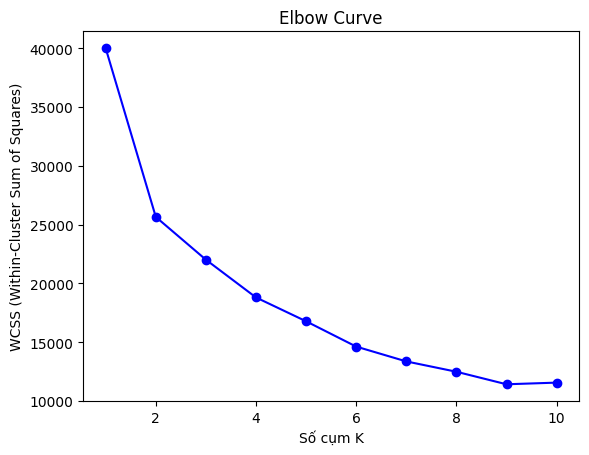

In [19]:
elbow_curve(df, 10)

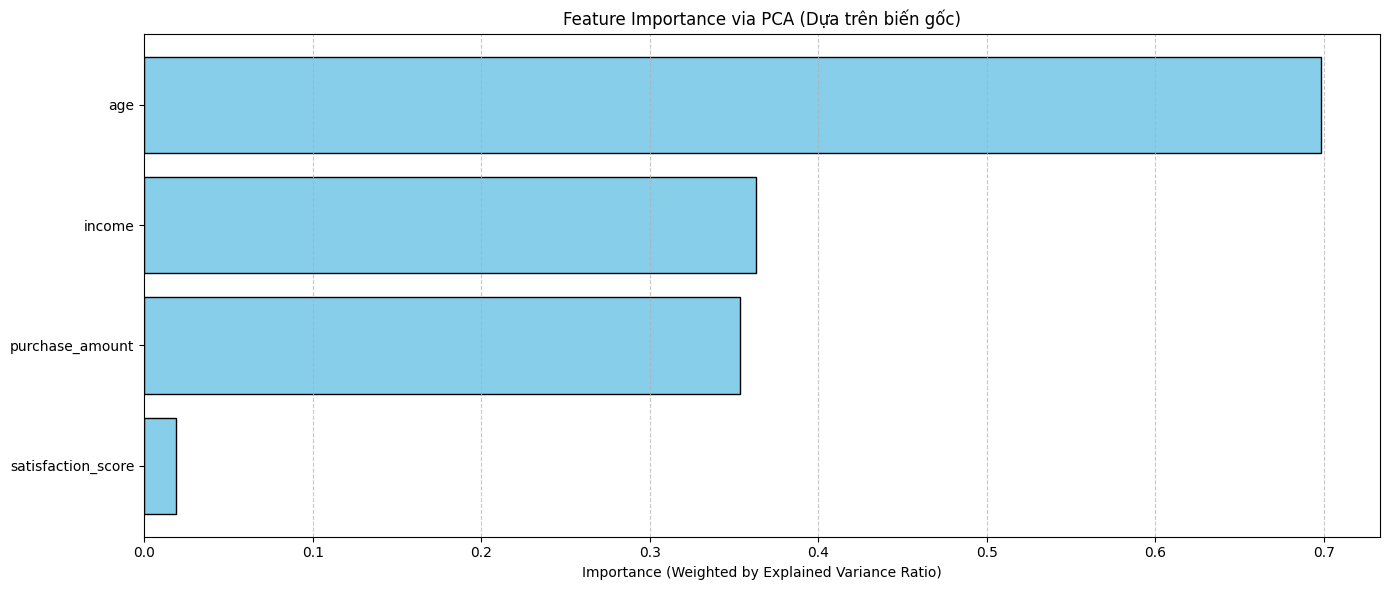

In [15]:
# Bước 1: PCA đầy đủ (full component)
df_encoded = df
categorical_num_cols = ['age','income','purchase_amount','satisfaction_score']  

scaler = StandardScaler()
df_encoded[categorical_num_cols] = scaler.fit_transform(df_encoded[categorical_num_cols])

pca = PCA()
X_pca = pca.fit_transform(df_encoded)

# Bước 2: Tính ma trận loading
loadings = pca.components_.T  # shape: (n_features, n_components)

# Bước 3: Tính importance của từng biến gốc
# Tổng tỉ trọng (weighted loading) trên tất cả các thành phần chính
importance_weighted = np.sum(
    (np.abs(loadings).T * pca.explained_variance_ratio_).T, axis=1
)

# Bước 4: Đưa vào DataFrame
feature_importance = pd.DataFrame({
    'Feature': df.columns,
    'Importance': importance_weighted
}).sort_values(by='Importance', ascending=True)

# Bước 5: Vẽ biểu đồ
plt.figure(figsize=(14, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue', edgecolor='black')
plt.xlabel("Importance (Weighted by Explained Variance Ratio)")
plt.title("Feature Importance via PCA (Dựa trên biến gốc)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Biến sẽ bị loại bỏ: ['satisfaction_score']
           age    income  purchase_amount
0    -0.667454  1.014020         1.811069
1    -0.220727 -0.942540        -1.061468
2     1.566178  0.872629         0.462705
3     0.002636 -1.231724        -1.157765
4     0.225999  1.497664         2.112337
...        ...       ...              ...
9995 -1.114180 -1.317576        -1.122729
9996 -0.444091  1.187808         1.911561
9997 -0.667454 -0.484737        -0.771319
9998  1.119451  0.654179         0.536344
9999 -0.667454  1.065778         1.138041

[10000 rows x 3 columns]
[[ 2.01051104 -0.62800884]
 [-1.41238282 -0.24878384]
 [ 0.91291559  1.58482527]
 ...
 [-0.87472944 -0.68483293]
 [ 0.81941675  1.13601337]
 [ 1.5712904  -0.63639209]]


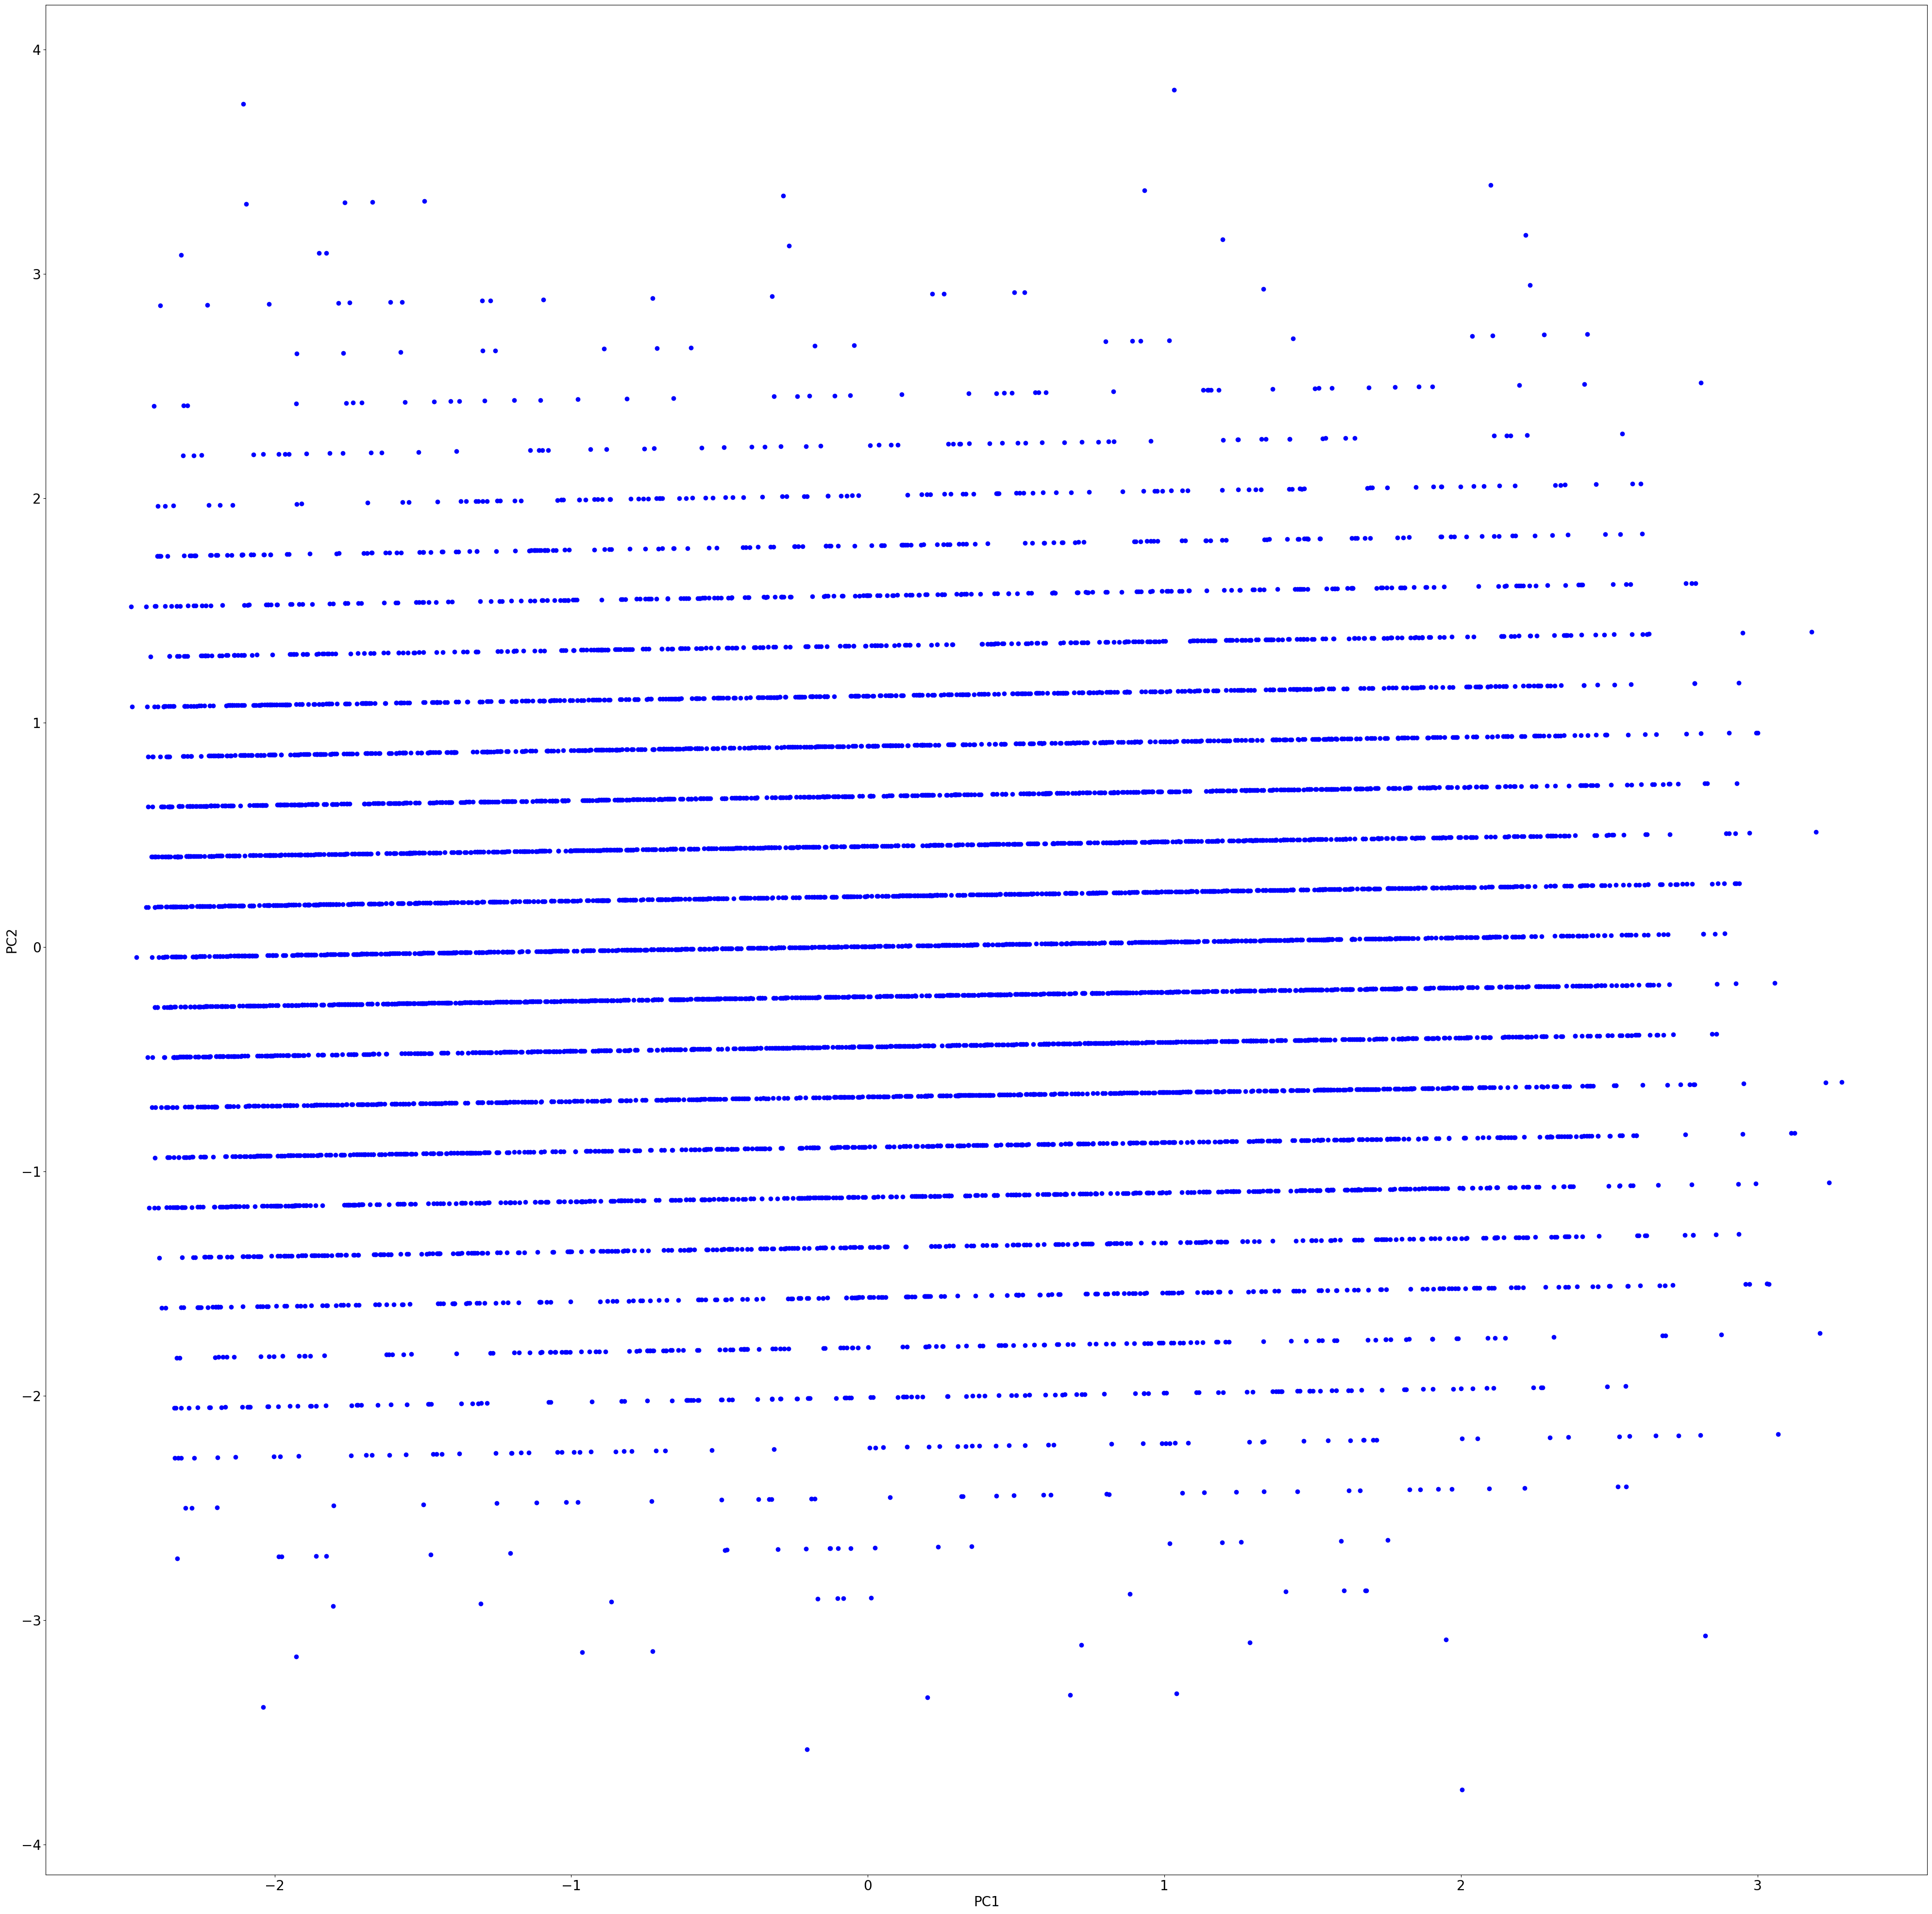

In [16]:
threshold = 0.2
low_importance_features = df.columns[importance_weighted < threshold]
print("Biến sẽ bị loại bỏ:", list(low_importance_features))

df_new = df.drop(columns=low_importance_features)
print(df_new)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_new)
print(X_pca)

plt.figure(figsize=(50, 50))
plt.scatter(X_pca[:,0], X_pca[:,1], color='b')
plt.xlabel('PC1', fontsize = 20)
plt.ylabel('PC2', fontsize = 20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()


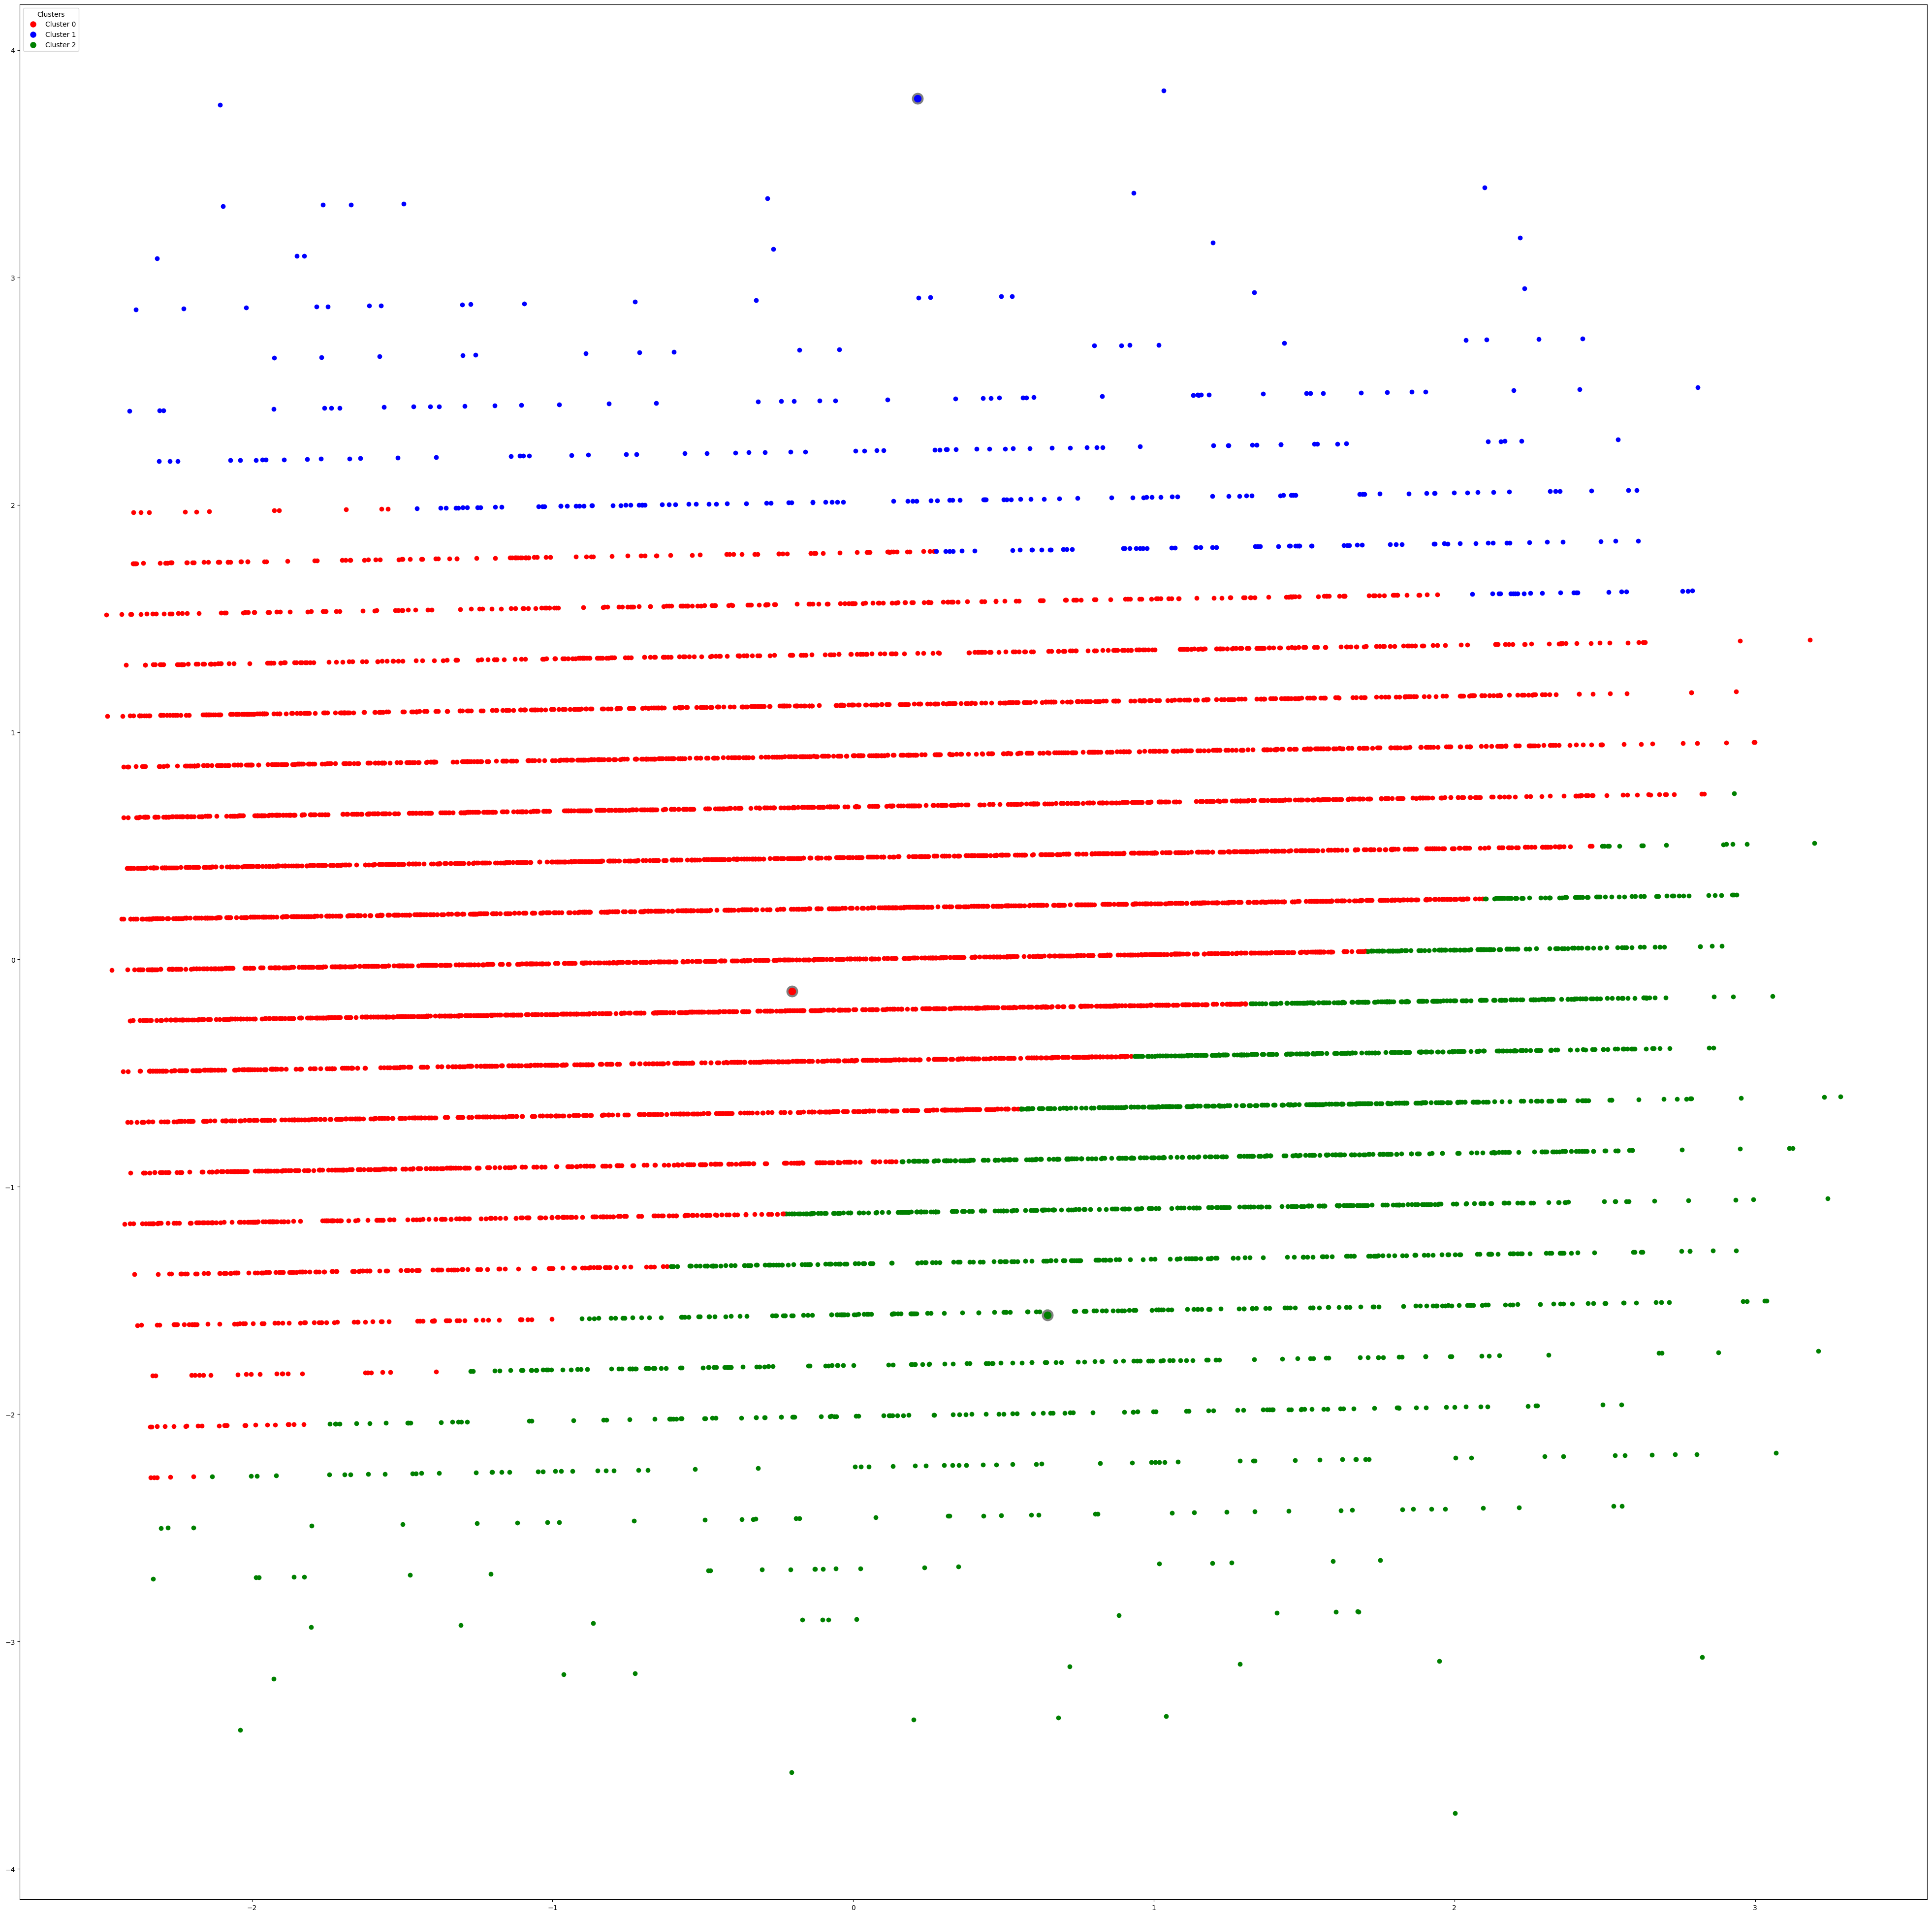

Centroids:
[[-0.20348887 -0.14070793]
 [ 0.21416462  3.78714772]
 [ 0.64616891 -1.56325407]]

Fitting for 100 epochs with step of 1
Done fitting!

[2 0 1 ... 0 1 2]
Centroids:
[[-1.33564013 -0.00714898]
 [ 1.00549514  0.94321427]
 [ 1.07131287 -0.75712497]]


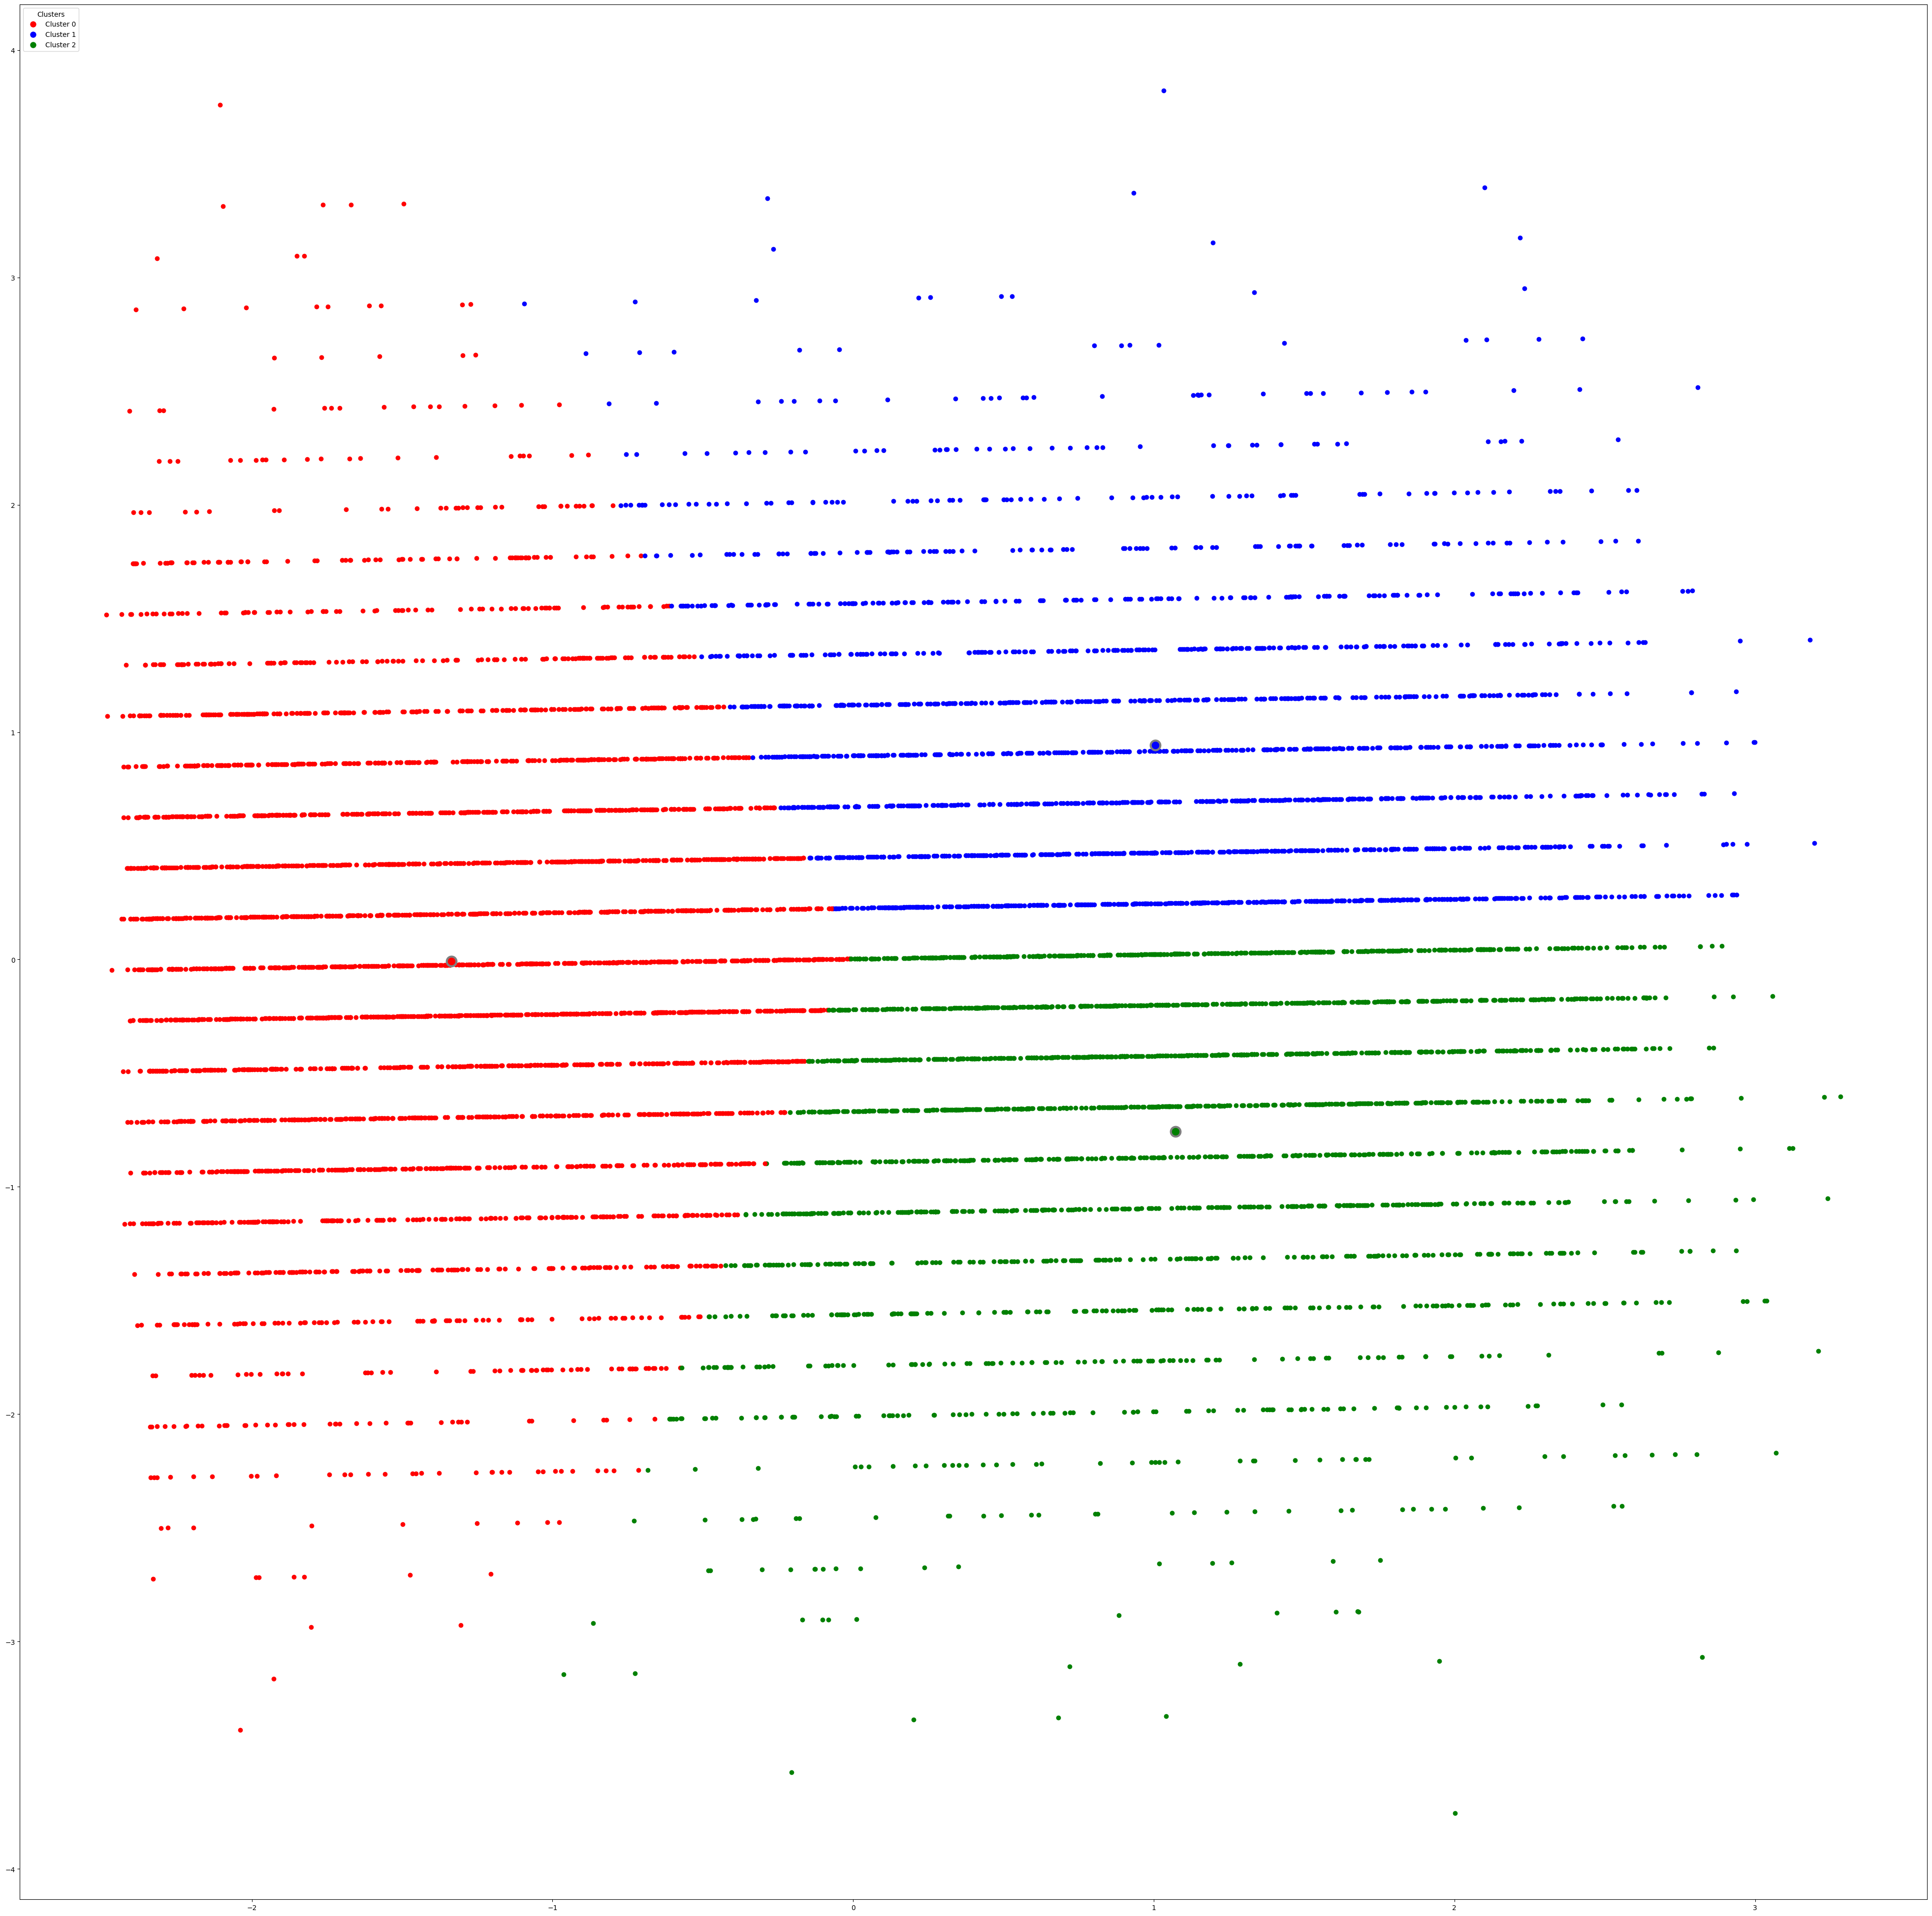

In [17]:
kmeans = KMeans(n_clusters=3, data=X_pca)
kmeans.showPlot(classification=True)
kmeans.printCentroids()
kmeans.fit(epochs=100, step=1)
pred = kmeans.genLabels()
print(pred)
kmeans.printCentroids()
kmeans.showPlot(classification=True)